The digit: 7


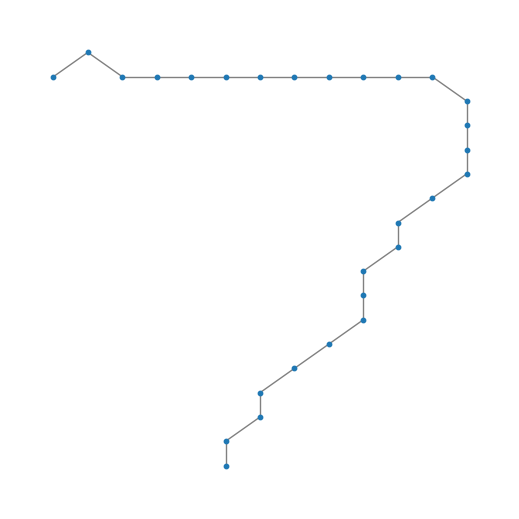

In [2]:
import numpy as np
import networkx as nx
import cv2
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from sklearn.metrics import pairwise_distances
from tensorflow.keras.datasets import mnist

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

def preprocess_image(image):
    """Convert an image to binary and skeletonize it."""
    _, binary = cv2.threshold(image, 128, 255, cv2.THRESH_BINARY)
    skeleton = skeletonize(binary // 255)
    return skeleton

def extract_graph(image):
    """Extract a graph from a skeletonized image."""
    points = np.column_stack(np.where(image > 0))  # Get nonzero pixel locations
    G = nx.Graph()
    for i, (y, x) in enumerate(points):
        G.add_node(i, pos=(x, -y))  # Store (x, -y) for correct visualization
        # Connect to nearest neighbors
        for j in range(i):
            y2, x2 = points[j]
            if abs(x - x2) <= 1 and abs(y - y2) <= 1:
                G.add_edge(i, j)
    return G

def plot_graph(G):
    """Visualize the extracted graph."""
    pos = nx.get_node_attributes(G, 'pos')
    plt.figure(figsize=(5, 5))
    nx.draw(G, pos, node_size=10, edge_color='gray', with_labels=False)
    plt.show()

# Test on a sample digit
test_image = x_test[0]  # Select a digit
print("The digit: {}".format(y_test[0]))
skeleton = preprocess_image(test_image)
G = extract_graph(skeleton)
plot_graph(G)

## Graph method applied to every digit from mnist - 10 examples of the digits

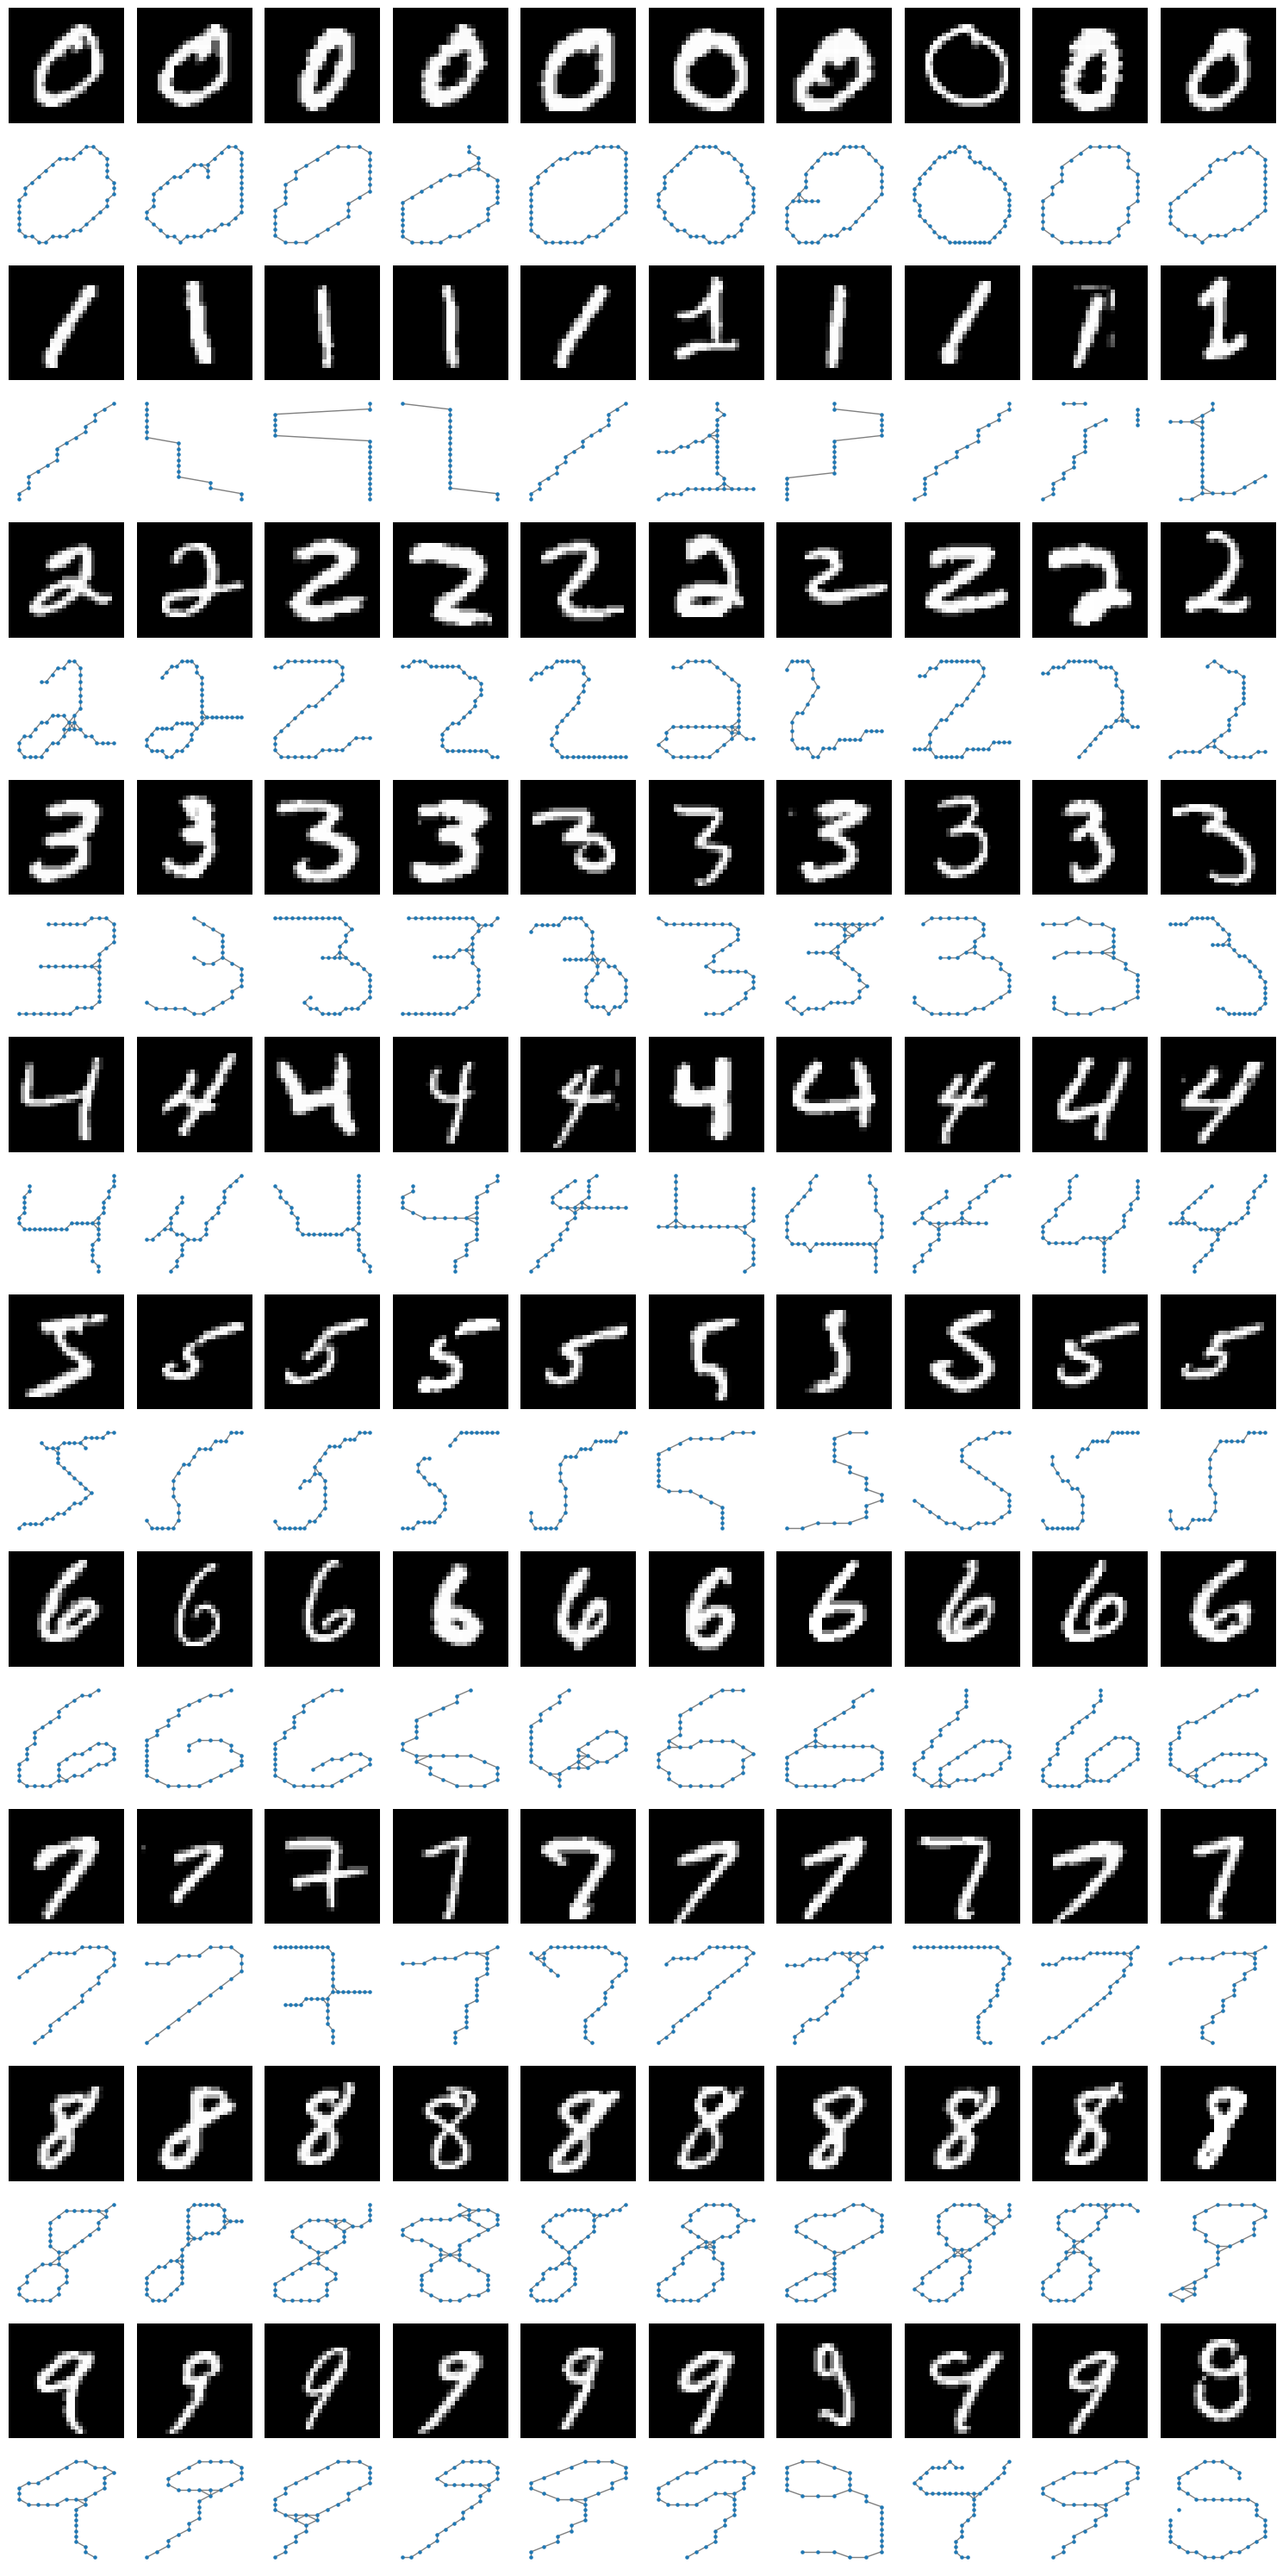

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from skimage.morphology import skeletonize
from tensorflow.keras.datasets import mnist

def preprocess_image(image):
    """Preprocess the image to obtain its skeleton."""
    _, binary = cv2.threshold(image, 128, 255, cv2.THRESH_BINARY)
    skeleton = skeletonize(binary // 255)
    return skeleton

## Only sparse connections betweeen nodes 
# def extract_graph00(skeleton):
#     """Extract a graph from the skeleton image."""
#     G = nx.Graph()
#     for y in range(skeleton.shape[0]):
#         for x in range(skeleton.shape[1]):
#             if skeleton[y, x] == 1:  # Skeleton pixels are 1
#                 G.add_node((x, -y))  # Flip y-axis for better visualization
#                 if x > 0 and skeleton[y, x - 1] == 1:
#                     G.add_edge((x, -y), (x - 1, -y))
#                 if y > 0 and skeleton[y - 1, x] == 1:
#                     G.add_edge((x, -y), (x, -y + 1))
#     return G


## Ensures more connections betweeen nodes
def extract_graph(skeleton):
    """Extract a well-connected graph from a skeletonized image."""
    G = nx.Graph()
    height, width = skeleton.shape

    # Define 8-neighbor connectivity (left, right, up, down, diagonals)
    neighbors = [
        (-1, 0), (1, 0),  # Left, Right
        (0, -1), (0, 1),  # Up, Down
        (-1, -1), (-1, 1), (1, -1), (1, 1)  # Diagonal connections
    ]

    for y in range(height):
        for x in range(width):
            if skeleton[y, x] == 1:  # If pixel is part of the skeleton
                node = (x, -y)  # Flip y-axis for correct orientation
                G.add_node(node)

                # Connect to valid 8-neighbors
                for dx, dy in neighbors:
                    nx_pos, ny_pos = x + dx, y + dy
                    neighbor_node = (nx_pos, -ny_pos)  # Flip y-axis for consistency

                    if 0 <= nx_pos < width and 0 <= ny_pos < height and skeleton[ny_pos, nx_pos] == 1:
                        weight = 1 if abs(dx) + abs(dy) == 1 else np.sqrt(2)  # Euclidean distance for diagonals
                        G.add_edge(node, neighbor_node, weight=weight)

    return G

def plot_graph(G, ax):
    """Plot the graph on the given axis."""
    pos = {node: node for node in G.nodes()}
    nx.draw(G, pos, ax=ax, node_size=5, edge_color='gray', with_labels=False)

# Load the MNIST dataset
(x_train, y_train), _ = mnist.load_data()

# Create a figure with 20 rows (10 digits, each with image + graph) and 10 columns
fig, axes = plt.subplots(20, 10, figsize=(15, 30))

for i in range(10):
    images = x_train[y_train == i][:10]  # Get first 10 images of digit i
    for j, image in enumerate(images):
        axes[2 * i, j].imshow(image, cmap='gray')
        axes[2 * i, j].axis('off')
        
        skeleton = preprocess_image(image)
        G = extract_graph(skeleton)
        
        plot_graph(G, axes[2 * i + 1, j])
        axes[2 * i + 1, j].axis('off')

plt.tight_layout()
plt.show()

## 02. Find cycles

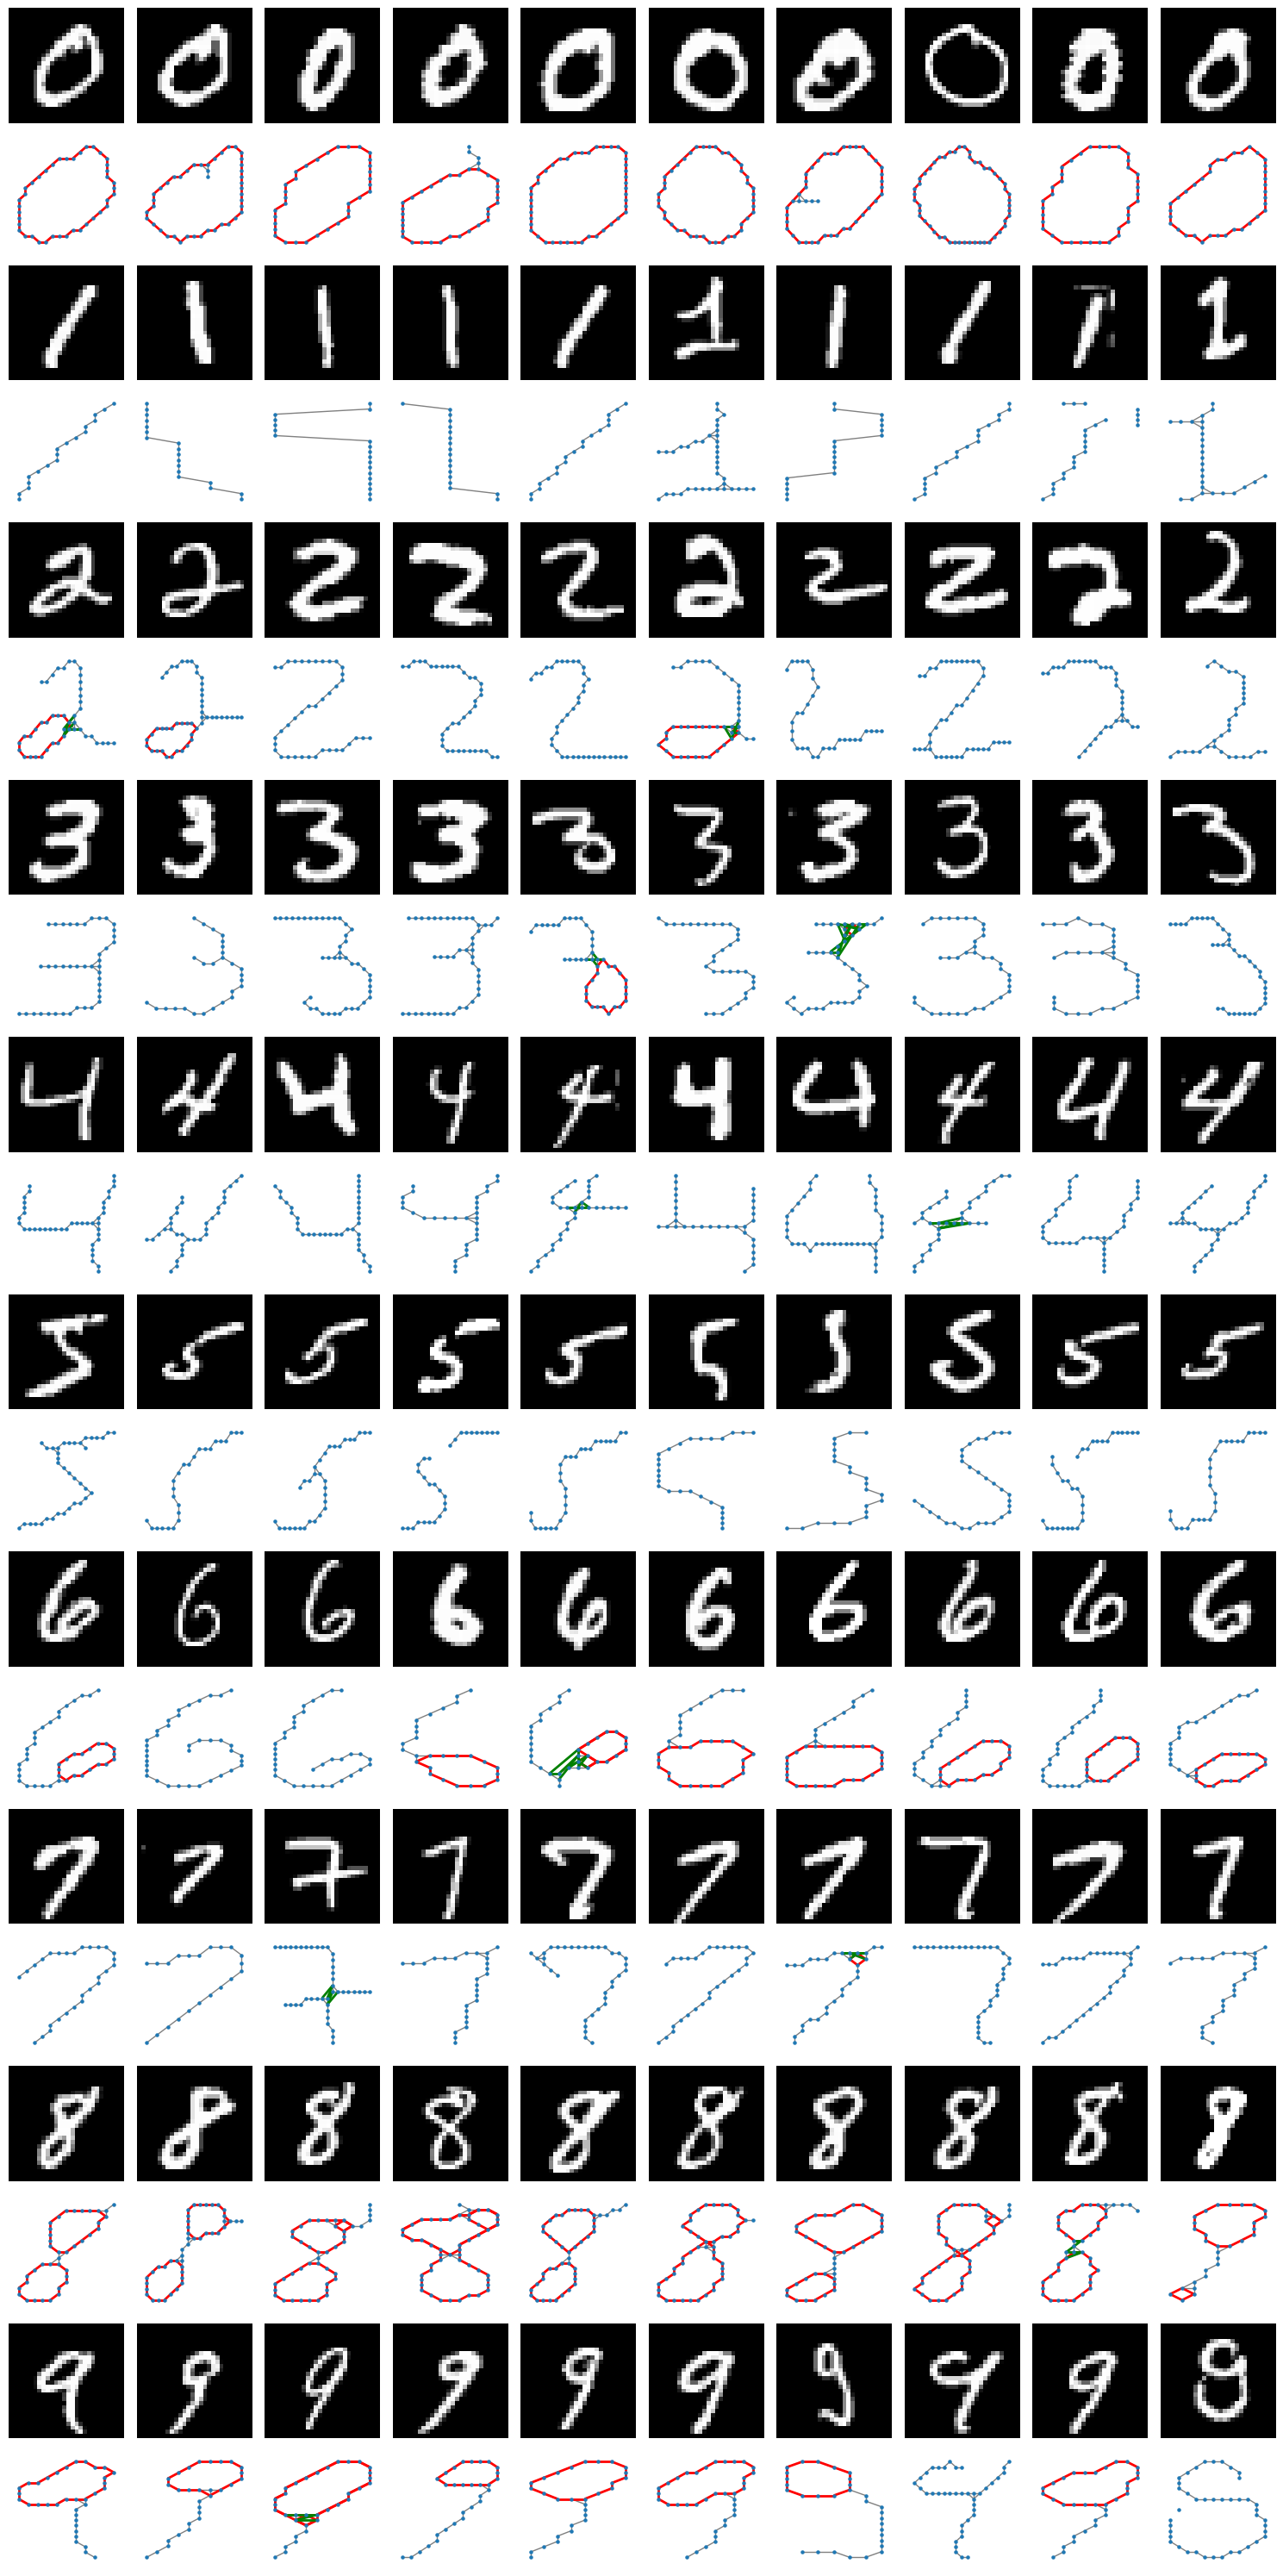

In [40]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from skimage.morphology import skeletonize
from tensorflow.keras.datasets import mnist

def preprocess_image(image):
    """Preprocess the image to obtain its skeleton."""
    _, binary = cv2.threshold(image, 128, 255, cv2.THRESH_BINARY)
    skeleton = skeletonize(binary // 255)
    return skeleton

def extract_graph(skeleton):
    """Extract a well-connected graph from a skeletonized image."""
    G = nx.Graph()
    height, width = skeleton.shape

    # Define 8-neighbor connectivity (left, right, up, down, diagonals)
    neighbors = [
        (-1, 0), (1, 0),  # Left, Right
        (0, -1), (0, 1),  # Up, Down
        (-1, -1), (-1, 1), (1, -1), (1, 1)  # Diagonal connections
    ]

    for y in range(height):
        for x in range(width):
            if skeleton[y, x] == 1:  # If pixel is part of the skeleton
                node = (x, -y)  # Flip y-axis for correct orientation
                G.add_node(node)

                # Connect to valid 8-neighbors
                for dx, dy in neighbors:
                    nx_pos, ny_pos = x + dx, y + dy
                    neighbor_node = (nx_pos, -ny_pos)  # Flip y-axis for consistency

                    if 0 <= nx_pos < width and 0 <= ny_pos < height and skeleton[ny_pos, nx_pos] == 1:
                        weight = 1 if abs(dx) + abs(dy) == 1 else np.sqrt(2)  # Euclidean distance for diagonals
                        G.add_edge(node, neighbor_node, weight=weight)

    return G

def find_cycles(G):
    """Find all cycles in the graph using NetworkX's cycle basis method."""
    cycles = nx.cycle_basis(G)  # List of cycles (each cycle is a list of nodes)

    # filter out cycles with less than 4 nodes (not meaningful for digits)
    cycles = [cycle for cycle in cycles if len(cycle) > 3]
    return cycles


def find_almost_cycles(G, clustering_threshold=0.1, eccentricity_threshold=2):
    """
    Detect open but nearly closed cycles based on graph topology.
    
    Parameters:
        - G: Graph (NetworkX)
        - clustering_threshold: Minimum clustering coefficient for cycle candidates.
        - eccentricity_threshold: Nodes with high eccentricity are less likely part of cycles.
        
    Returns:
        - List of "almost cycles" (chains that almost form closed loops).
    """
    # Step 1: Find high-clustering nodes (circular candidates)
    clustering = nx.clustering(G)
    high_clustering_nodes = [node for node, coeff in clustering.items() if coeff >= clustering_threshold]

    # Step 2: Compute eccentricity (how far a node is from others)
    if nx.is_connected(G):
        eccentricity = nx.eccentricity(G)  # Eccentricity = max shortest path distance
    else:
        eccentricity = {node: float('inf') for node in G.nodes()}  # If disconnected, default to infinity

    # Step 3: Filter nodes with low eccentricity (likely near closed structures)
    cycle_candidates = [node for node in high_clustering_nodes if eccentricity[node] <= eccentricity_threshold]

    # Step 4: Extract subgraph & identify "almost cycles"
    subgraph = G.subgraph(cycle_candidates)  
    components = list(nx.connected_components(subgraph))

    # Step 5: Filter out very small components (no meaningful near-cycles)
    #almost_cycles = [list(comp) for comp in components if len(comp) > 3]
    almost_cycles = [list(comp) for comp in components]
    return almost_cycles

import networkx as nx
import numpy as np

def find_ellipsoid_like_structures(G, clustering_threshold=0.01, curvature_threshold=0.05):
    """
    Detect ellipsoid-like structures in the graph using clustering, curvature, and centrality.
    
    Parameters:
        - G: Graph (NetworkX)
        - clustering_threshold: Nodes with at least this clustering coefficient are considered.
        - curvature_threshold: Nodes with moderate curvature indicate ellipsoid-like regions.
    
    Returns:
        - List of "ellipsoid-like" components (node groups forming elongated loops).
    """
    # Step 1: Compute Clustering Coefficients
    clustering = nx.clustering(G)
    candidate_nodes = [node for node, coeff in clustering.items() if coeff >= clustering_threshold]

    # Step 2: Compute Edge Betweenness Centrality (important edges in paths)
    edge_centrality = nx.edge_betweenness_centrality(G)
    high_centrality_edges = [edge for edge, score in edge_centrality.items() if score > 0.1]

    # Step 3: Find Subgraphs of High-Clustering Nodes
    subgraph = G.subgraph(candidate_nodes)
    components = list(nx.connected_components(subgraph))

    ellipsoid_structures = []
    for comp in components:
        if len(comp) > 4:  # Filter out small components
            subG = G.subgraph(comp)

            # Step 4: Check if the structure is elongated (high eccentricity)
            eccentricity = nx.eccentricity(subG) if nx.is_connected(subG) else {}
            avg_eccentricity = np.mean(list(eccentricity.values())) if eccentricity else 0

            # Step 5: Check if the structure has curved paths (using edge centrality)
            curved_edges = [edge for edge in subG.edges if edge in high_centrality_edges]
            curvature_score = len(curved_edges) / len(subG.edges) if subG.edges else 0

            # If eccentricity is moderate & curvature score is high, it's ellipsoid-like
            if avg_eccentricity > 2 and curvature_score > curvature_threshold:
                ellipsoid_structures.append(list(comp))

    return ellipsoid_structures



def plot_graph(G, ax, highlight_cycles=False, cycles=[], almost_cycles=[], ellipsoids=[]):
    """Plot the graph on the given axis with optional cycle highlighting."""
    pos = {node: node for node in G.nodes()}  # Use node positions as coordinates
    
    # Draw the full graph in gray
    nx.draw(G, pos, ax=ax, node_size=5, edge_color='gray', with_labels=False)
    
    if highlight_cycles:
        # Draw cycles with different colors
        for cycle in cycles:
            cycle_edges = [(cycle[i], cycle[i + 1]) for i in range(len(cycle) - 1)] + [(cycle[-1], cycle[0])]
            nx.draw_networkx_edges(G, pos, edgelist=cycle_edges, ax=ax, edge_color='red', width=2)

        # Draw "almost cycles" with different colors
        for cycle in almost_cycles:
            cycle_edges = [(cycle[i], cycle[i + 1]) for i in range(len(cycle) - 1)]
            nx.draw_networkx_edges(G, pos, edgelist=cycle_edges, ax=ax, edge_color='blue', width=2)

        # Draw "ellipsoid-like" structures with different colors
        for cycle in ellipsoids:
            cycle_edges = [(cycle[i], cycle[i + 1]) for i in range(len(cycle) - 1)]
            nx.draw_networkx_edges(G, pos, edgelist=cycle_edges, ax=ax, edge_color='green', width=2)


# Load the MNIST dataset
(x_train, y_train), _ = mnist.load_data()

# Create a figure with 20 rows (10 digits, each with image + graph) and 10 columns
fig, axes = plt.subplots(20, 10, figsize=(15, 30))

for i in range(10):  # Iterate through digits 0-9
    images = x_train[y_train == i][:10]  # Get first 5 images of digit i
    for j, image in enumerate(images):
        axes[2 * i, j].imshow(image, cmap='gray')
        axes[2 * i, j].axis('off')
        
        skeleton = preprocess_image(image)
        G = extract_graph(skeleton)
        cycles = find_cycles(G)  # Detect cycles in the graph
        almost_cycles = find_almost_cycles(G)
        ellsoids = find_ellipsoid_like_structures(G)
        
        # Plot original graph
        plot_graph(G, axes[2 * i + 1, j], highlight_cycles=True, cycles=cycles, almost_cycles=almost_cycles, ellipsoids=ellsoids)
        axes[2 * i + 1, j].axis('off')

plt.tight_layout()
plt.show()


4


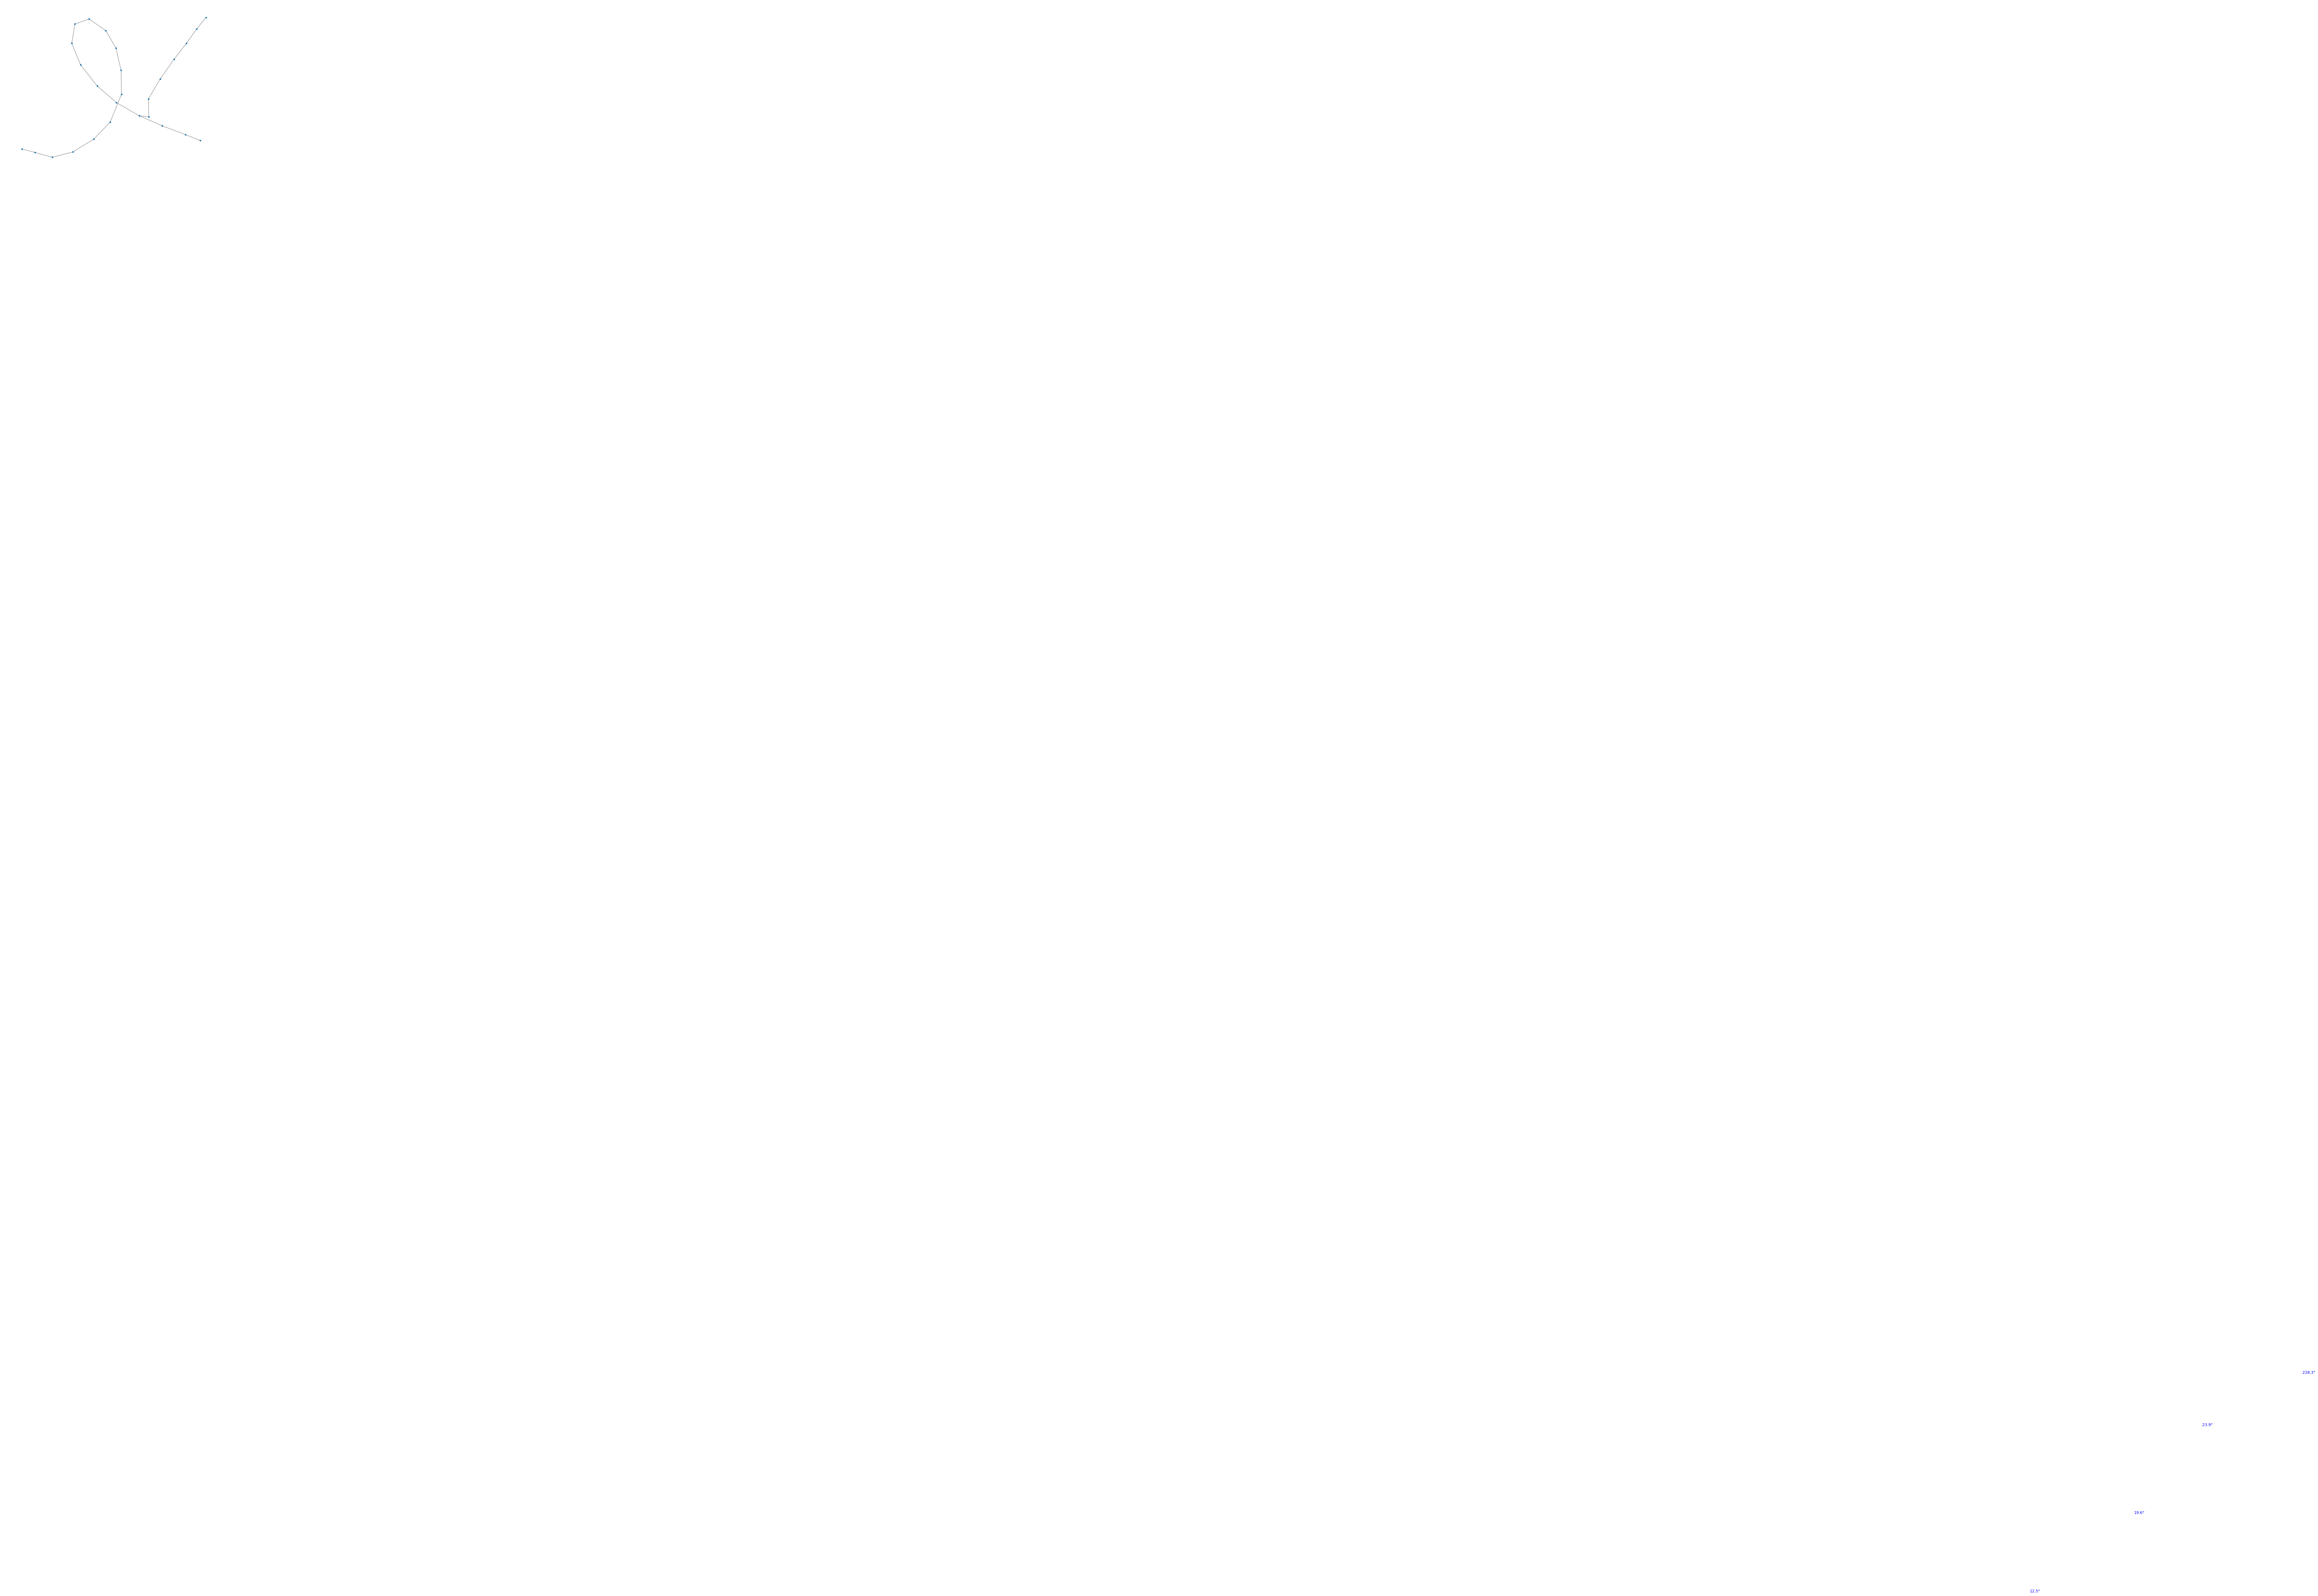

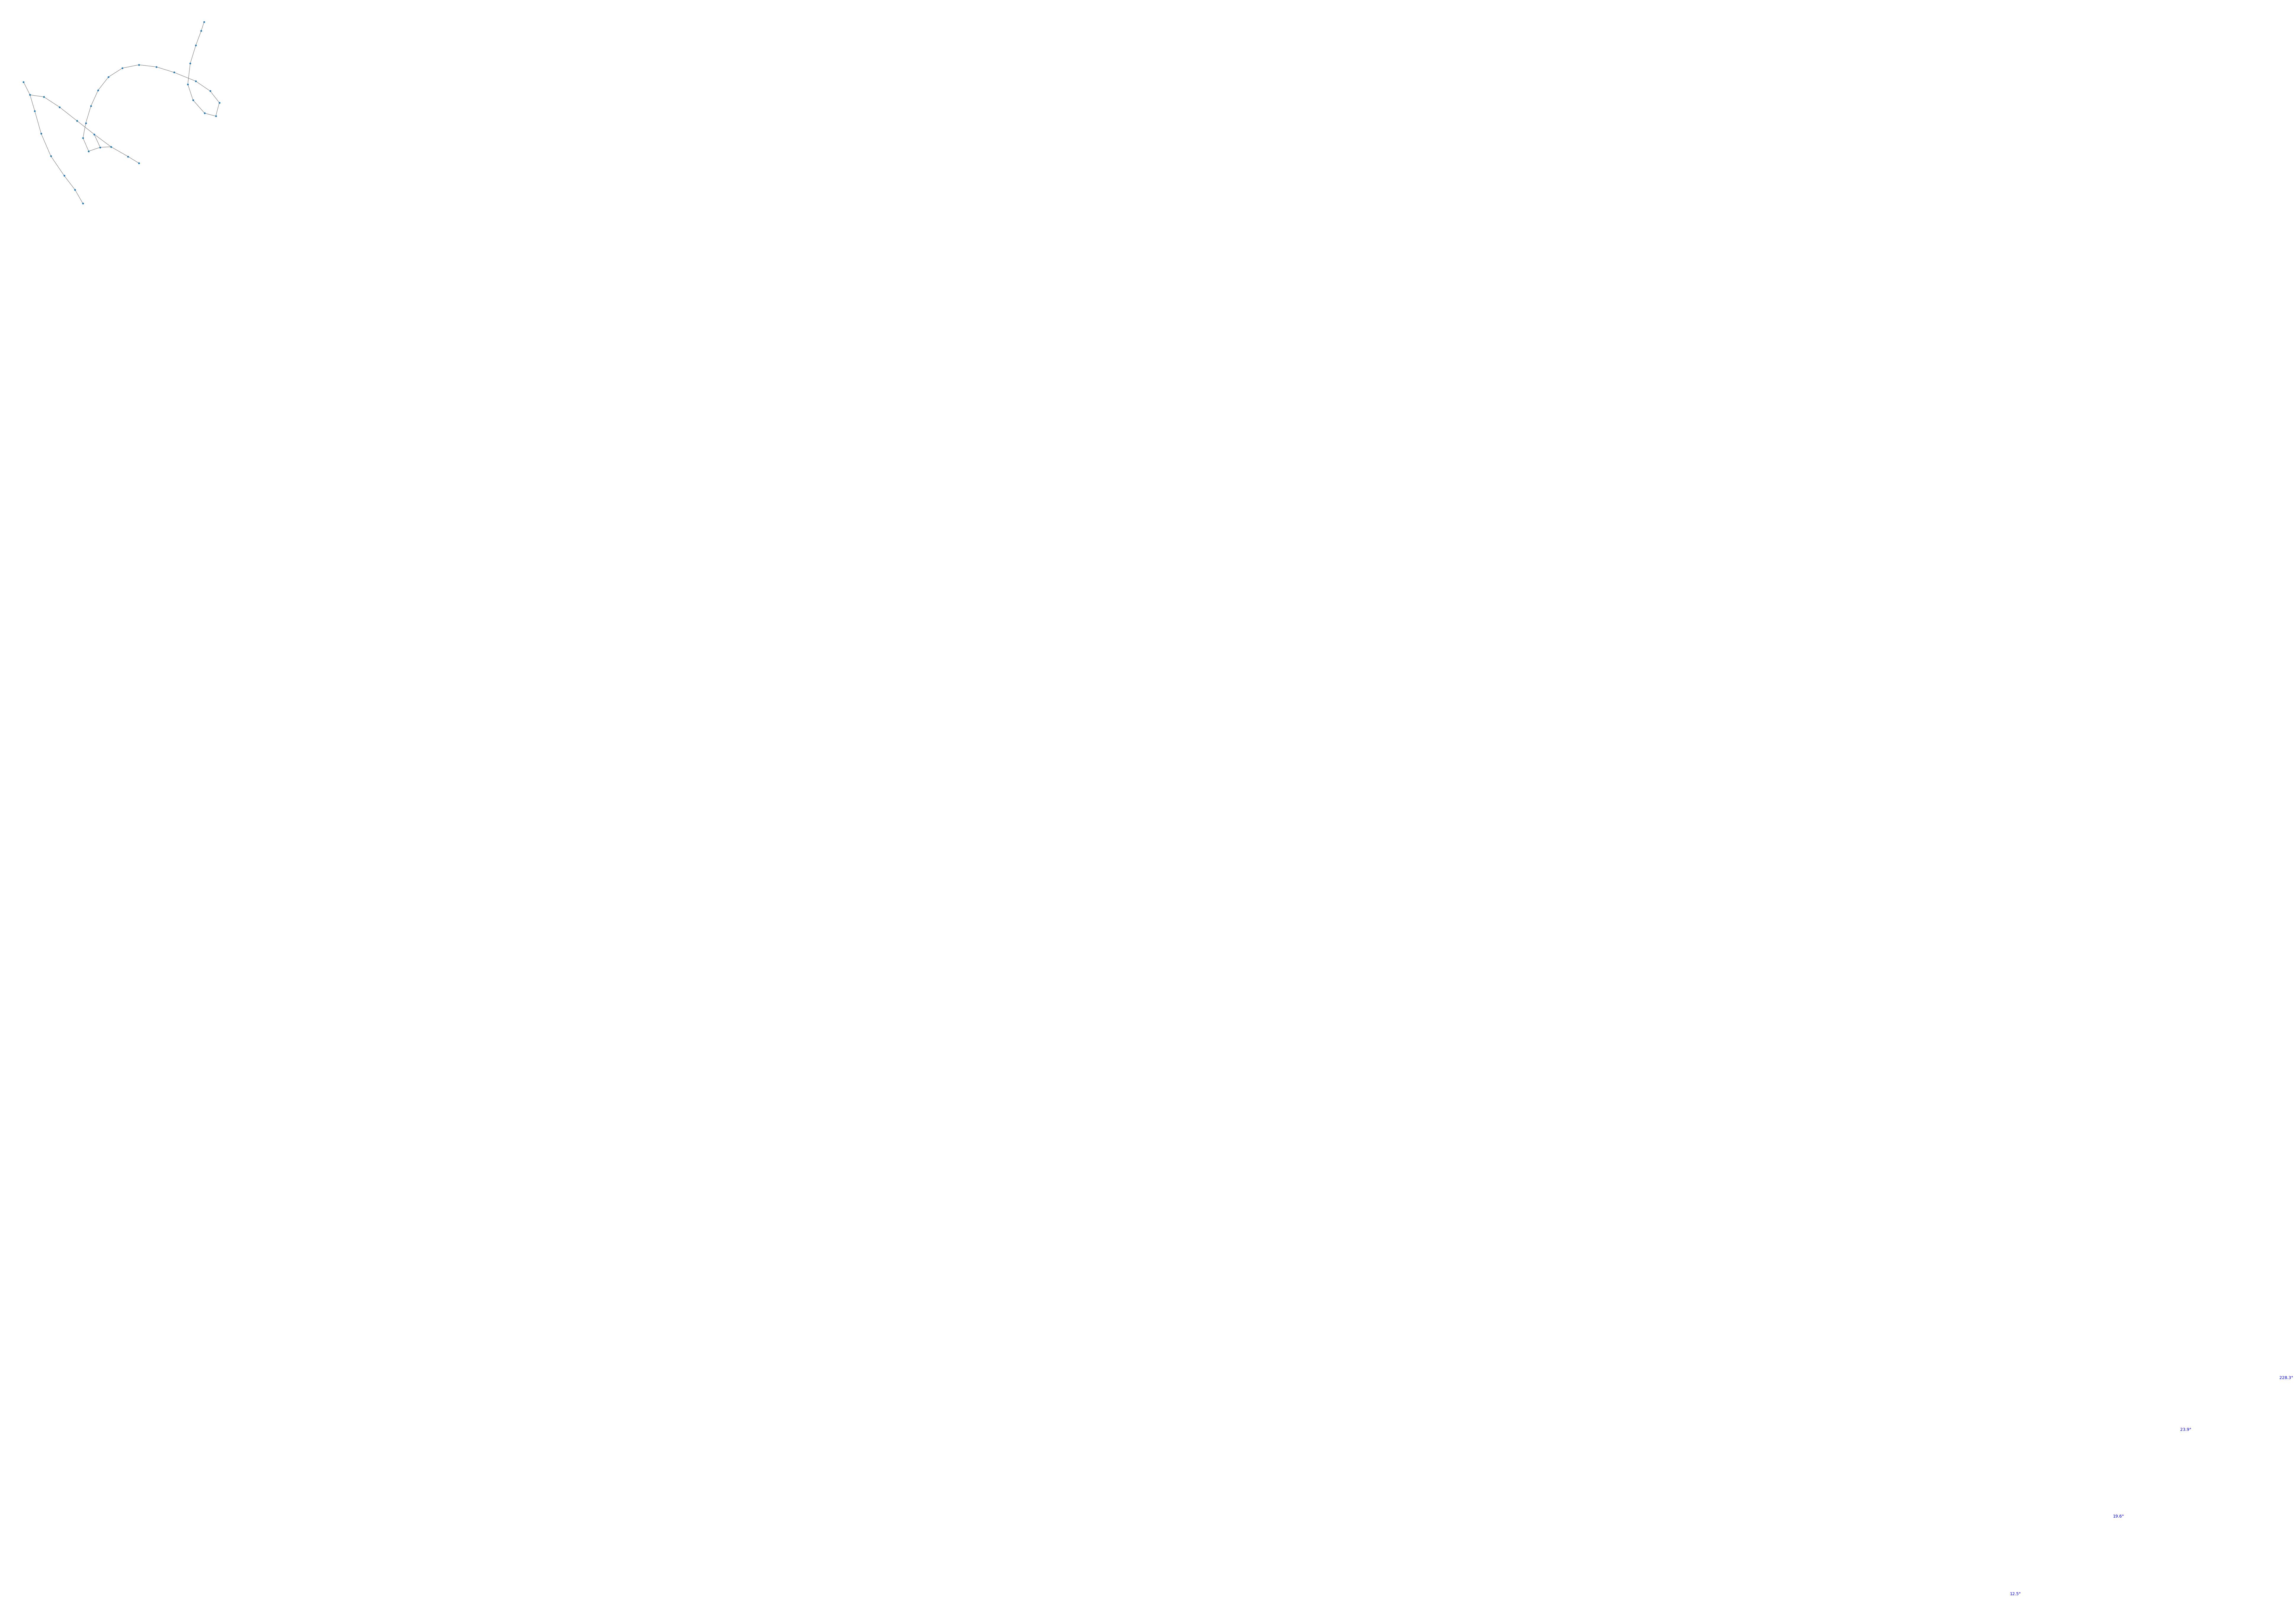

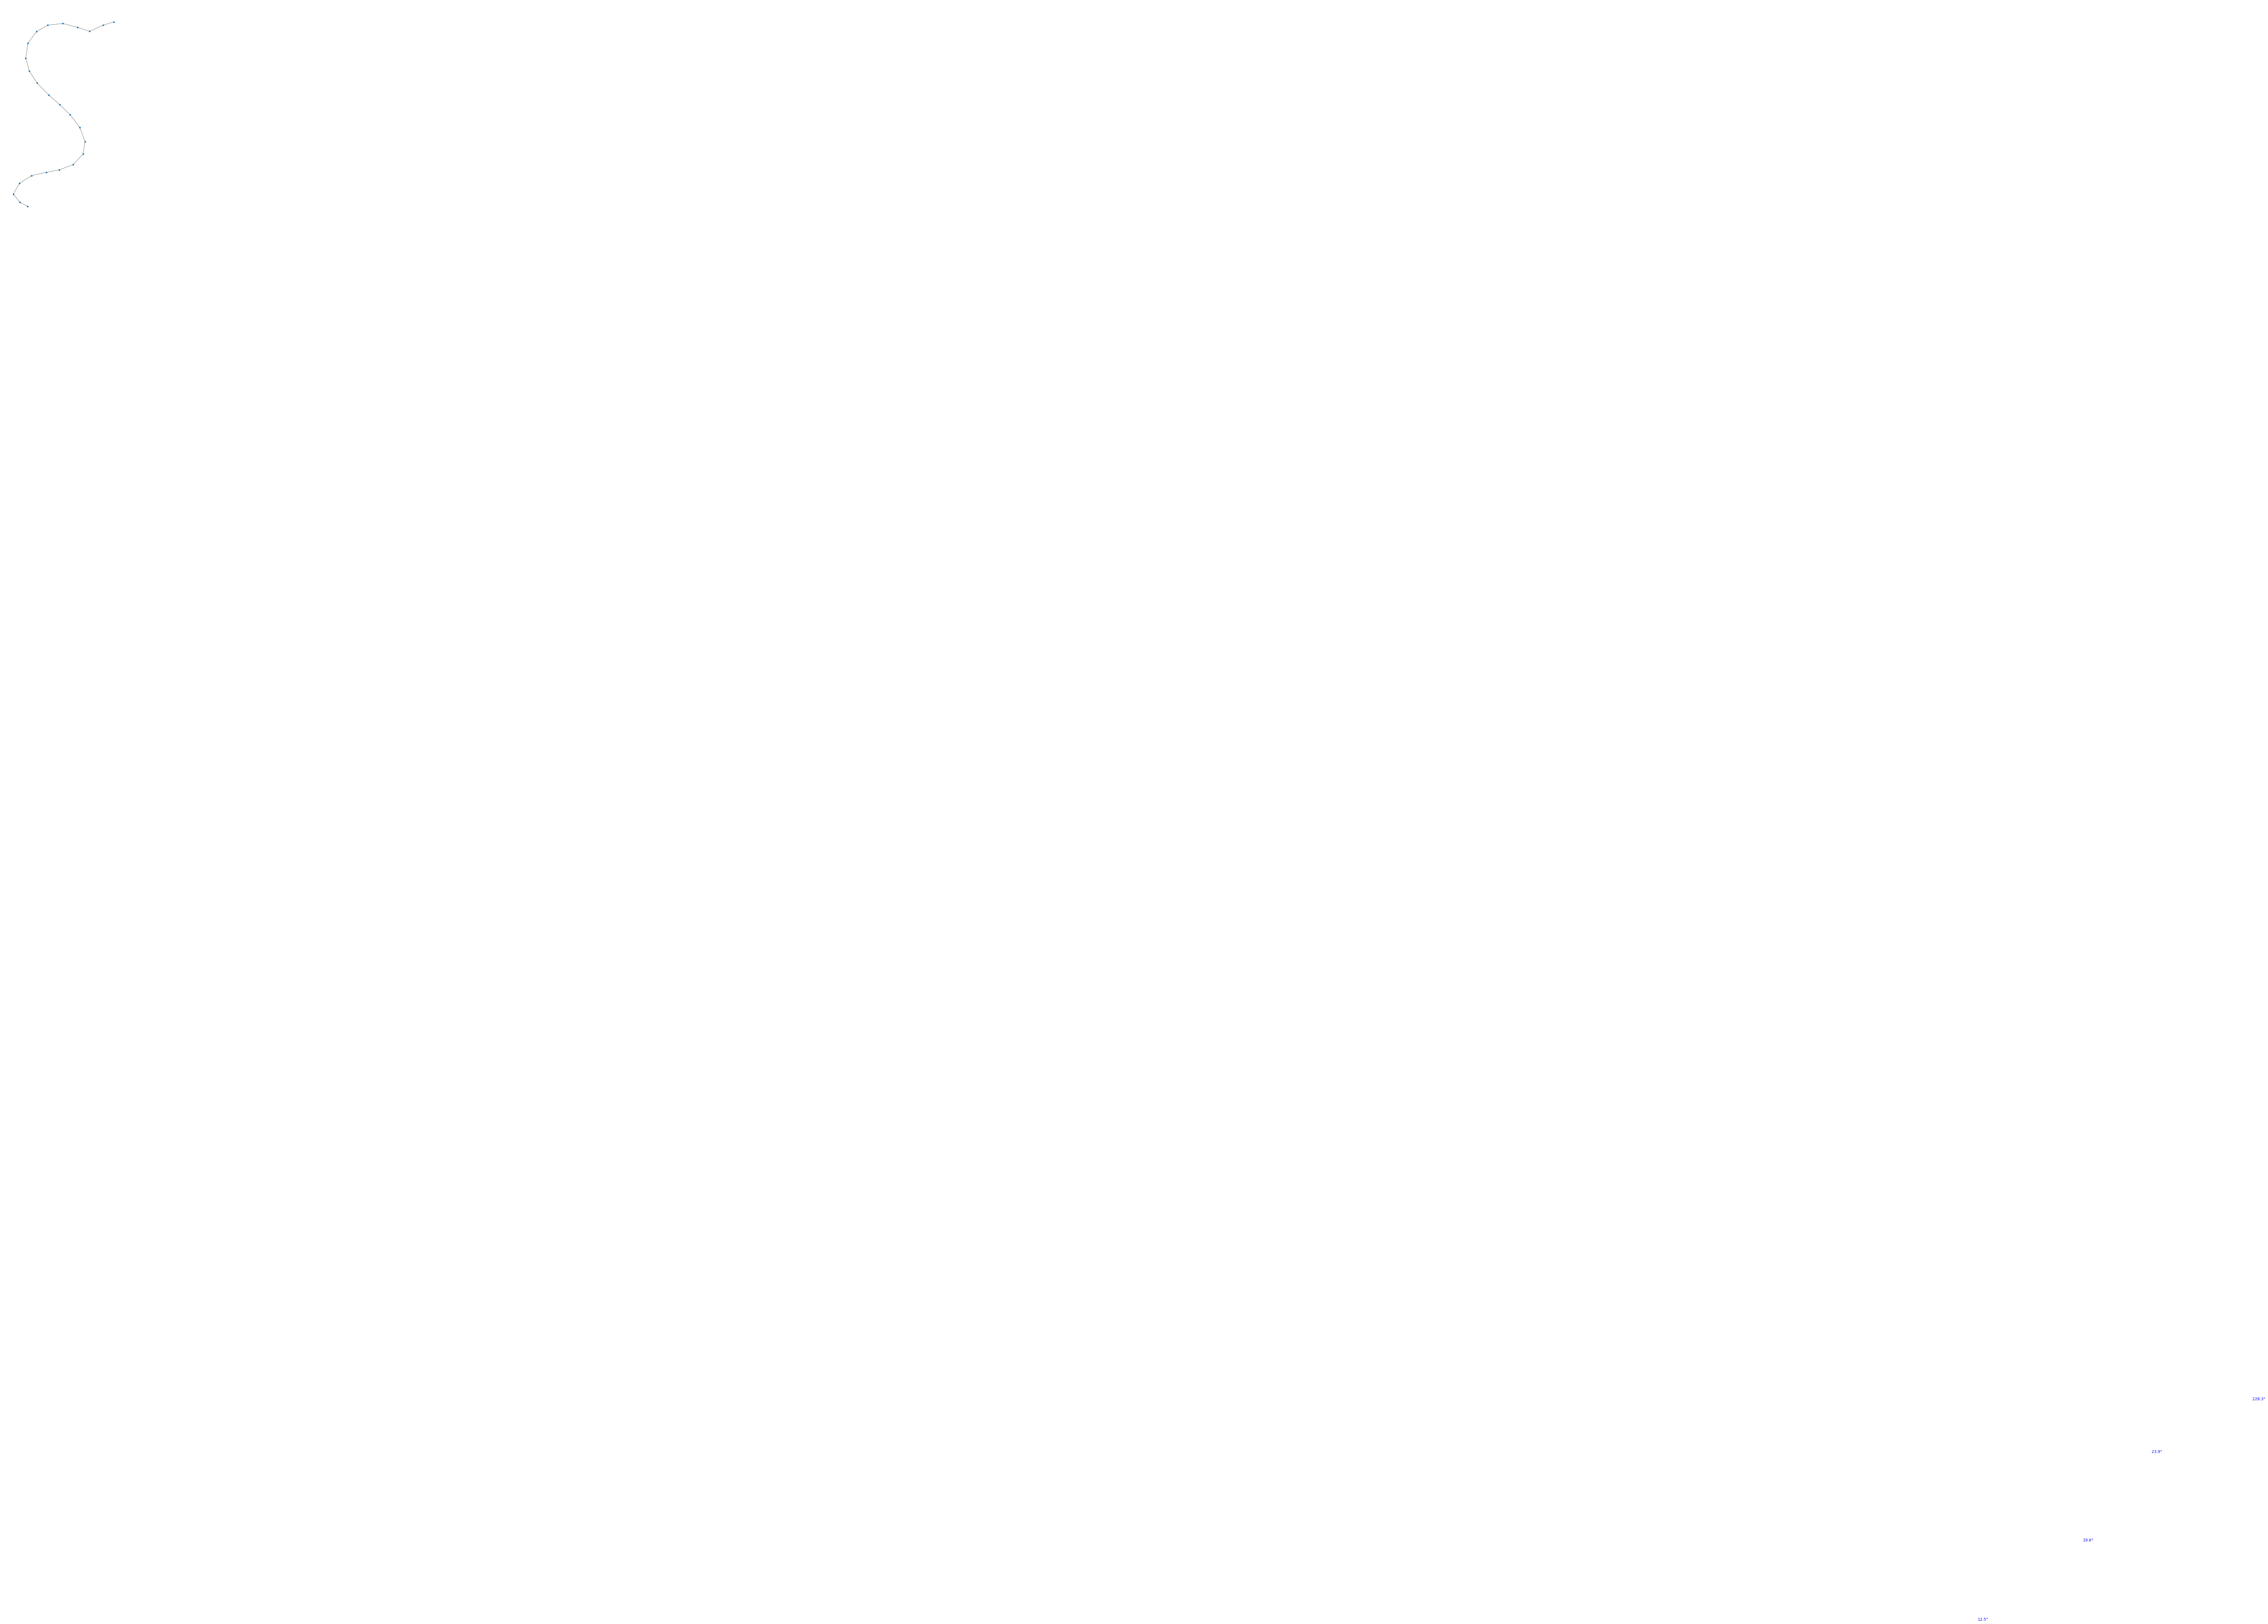

In [53]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.optimize import minimize
import cv2
from skimage.morphology import skeletonize
from matplotlib.patches import Ellipse  # Correct import

# Euclidean distance function
def euclidean_distance(node1, node2):
    """Compute Euclidean distance between two nodes."""
    return np.sqrt((node1[0] - node2[0])**2 + (node1[1] - node2[1])**2)

# Preprocess function to create skeleton
def preprocess_image(image):
    """Preprocess the image to obtain its skeleton."""
    _, binary = cv2.threshold(image, 128, 255, cv2.THRESH_BINARY)
    skeleton = skeletonize(binary // 255)
    return skeleton

# Function to fit an ellipse to points using PCA
def fit_ellipse_to_points(points):
    """Fit an ellipse to a set of points using PCA (Principal Component Analysis)."""
    pca = PCA(n_components=2)
    pca.fit(points)
    eigenvals = pca.explained_variance_
    
    # Semi-major and semi-minor axes
    a = np.sqrt(eigenvals[0])  # Semi-major axis
    b = np.sqrt(eigenvals[1])  # Semi-minor axis
    
    # Ellipse orientation (angle of rotation)
    angle = np.arctan2(pca.components_[1, 1], pca.components_[1, 0])  # rotation angle in radians
    
    # Find the center of the ellipse (mean of points)
    cx, cy = np.mean(points[:, 0]), np.mean(points[:, 1])
    
    return cx, cy, a, b, angle

# Function to detect curvature-like structures based on ellipse fitting
def find_curvatures(G, threshold=0.1):
    """
    Detect curvature-like structures (ellipsoid-like) in the graph based on Euclidean distance.
    
    Parameters:
        - G: Graph (NetworkX)
        - threshold: Threshold for curvature fitting.
    
    Returns:
        - List of curvature-like structures with parameters (origin, rx, ry, open angle).
    """
    curvatures = []

    # Iterate over all connected components
    for component in nx.connected_components(G):
        if len(component) < 3:
            continue  # Skip small components

        subgraph = G.subgraph(component)
        positions = np.array([node for node in subgraph.nodes()])

        # Fit an ellipse to the component
        cx, cy, a, b, angle = fit_ellipse_to_points(positions)

        # Calculate the curvature open angle (we'll use a heuristic here)
        angle_diff = angle % (2 * np.pi)  # Normalize angle
        
        # For simplicity, we'll assume if the ratio of axes (a/b) is large, we classify as open
        open_angle_deg = np.degrees(angle_diff)
        if open_angle_deg > 90:  # Only if the open angle is greater than 90 degrees
            open_angle_deg = 360 - open_angle_deg  # Reflect the angle in case it's a large curvature
            curvatures.append({
                'type': 'curvature',
                'origin': (cx, cy),
                'radii': (a, b),
                'open_angle': open_angle_deg
            })
    
    return curvatures

# Plot function to visualize the detected curvatures
def plot_curvatures_on_graphs(graphs, all_curvatures):
    """Visualize the detected curvatures on the graphs."""
    print(len(all_curvatures))
    for G in graphs:
        plt.figure(figsize=(8, 8))

        # Plot the original graph
        nx.draw(G, node_size=10, edge_color="gray", with_labels=False)

        # Plot the curvature-like structures
        for curvature in all_curvatures:
            origin = curvature['origin']
            rx, ry = curvature['radii']
            open_angle = curvature['open_angle']
            
            # Draw ellipse using the fitted parameters from matplotlib.patches.Ellipse
            ellipse = Ellipse(origin, 2 * rx, 2 * ry, angle=np.degrees(curvature['open_angle']),
                              color='r', fill=False, linewidth=2)
            plt.gca().add_artist(ellipse)
            
            plt.text(origin[0] + rx, origin[1], f'{open_angle:.1f}°', color='blue', fontsize=10)

        plt.gca().set_aspect('equal', adjustable='box')
        plt.show()

# Example usage with MNIST data
# Load MNIST dataset
from tensorflow.keras.datasets import mnist
(x_train, y_train), _ = mnist.load_data()

# Select the first 2 images for digits 7 and 5
images_7 = x_train[y_train == 3][:2]
images_5 = x_train[y_train == 5][:2]
images = np.concatenate([images_7, images_5], axis=0)

# Create graphs from the skeletonized images
graphs = []
for image in images:
    skeleton = preprocess_image(image)
    G = extract_graph(skeleton)  # Assuming this function is implemented elsewhere

    graphs.append(G)

# Find curvature-like structures in the graphs
all_curvatures = []
for G in graphs:
    curvatures = find_curvatures(G)
    all_curvatures.extend(curvatures)

# Visualize the curvatures detected in the graphs
plot_curvatures_on_graphs(graphs, all_curvatures)


## 03. Extract the common features in the graphs of the same digits

Graph 1 Features: [ 0. 40. 43. 30.]
Graph 2 Features: [32.  0. 51. 22.]
Graph 3 Features: [47. 55.  0. 49.]
Graph 4 Features: [26. 26. 43.  0.]


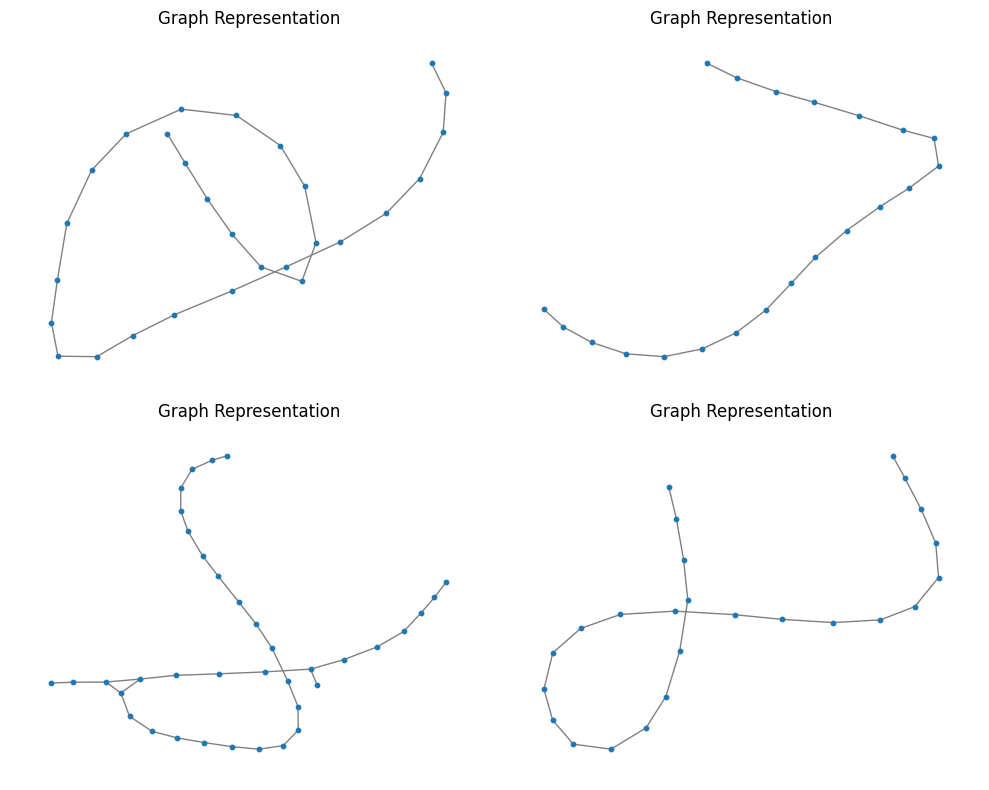

In [30]:
import networkx as nx
from networkx.algorithms.similarity import graph_edit_distance
import numpy as np
import cv2

def fisher_wagner_edit_distance(G1, G2):
    """
    Compute the graph edit distance using Fisher-Wagner approximation.
    Lower distance means graphs are more similar.
    """
    distance = graph_edit_distance(G1, G2, timeout=5)  # Now returns a float
    return distance if distance is not None else float('inf')  # Handle None case

def extract_graph_features(graphs):
    """
    Extract features from a list of graph representations of images.
    """
    n = len(graphs)
    feature_matrix = np.zeros((n, n))

    # Compute pairwise Fisher-Wagner edit distances
    for i in range(n):
        for j in range(n):
            if i != j:
                feature_matrix[i][j] = fisher_wagner_edit_distance(graphs[i], graphs[j])
            else:
                feature_matrix[i][j] = 0  # Distance with itself is 0

    return feature_matrix

def preprocess_image(image):
    """
    Convert an image to a skeletonized version for graph extraction.
    """
    #gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
    _, binary = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)  # Convert to binary
    skeleton = skeletonize(binary // 255)
    return skeleton

def extract_graph(skeleton):
    """Extract a well-connected graph from a skeletonized image."""
    G = nx.Graph()
    height, width = skeleton.shape

    # Define 8-neighbor connectivity (left, right, up, down, diagonals)
    neighbors = [
        (-1, 0), (1, 0),  # Left, Right
        (0, -1), (0, 1),  # Up, Down
        (-1, -1), (-1, 1), (1, -1), (1, 1)  # Diagonal connections
    ]

    for y in range(height):
        for x in range(width):
            if skeleton[y, x] == 1:  # If pixel is part of the skeleton
                node = (x, -y)  # Flip y-axis for correct orientation
                G.add_node(node)

                # Connect to valid 8-neighbors
                for dx, dy in neighbors:
                    nx_pos, ny_pos = x + dx, y + dy
                    neighbor_node = (nx_pos, -ny_pos)  # Flip y-axis for consistency

                    if 0 <= nx_pos < width and 0 <= ny_pos < height and skeleton[ny_pos, nx_pos] == 1:
                        weight = 1 if abs(dx) + abs(dy) == 1 else np.sqrt(2)  # Euclidean distance for diagonals
                        G.add_edge(node, neighbor_node, weight=weight)

    return G

# Define plot_graph function
def plot_graph(G, ax):
    """
    Plot a graph on a given axes (ax) with the nodes and edges.
    """
    #fixed_layout = nx.spring_layout(G, seed=42)  # Consistent layout for comparison
    # Plot the graph
    nx.draw(G, ax=ax, with_labels=False, node_size=10, edge_color="gray")
    ax.set_title("Graph Representation")

# Example Usage
images_7 = x_train[y_train == 7][:2]  # Get first 2 images of digit 7
images_5 = x_train[y_train == 5][:2]  # Get first 2 images of digit 5
images = np.concatenate([images_7, images_5], axis=0)  # Combine images

# Convert images into graph representations
graphs = [extract_graph(preprocess_image(images[i])) for i in range(len(images))]

# Compute feature matrix
feature_matrix = extract_graph_features(graphs)

# Print extracted features
for i, features in enumerate(feature_matrix):
    print(f"Graph {i+1} Features: {features}")

# Display graphs
fig, axes = plt.subplots(2, 2, figsize=(10, 8))  # Create a 2x2 grid of subplots
axes = axes.ravel()  # Flatten the axes array for easier indexing

for i in range(4):
    plot_graph(graphs[i], axes[i])  # Plot each graph in its corresponding subplot

plt.tight_layout()  # Adjust subplots to prevent overlap
plt.show()


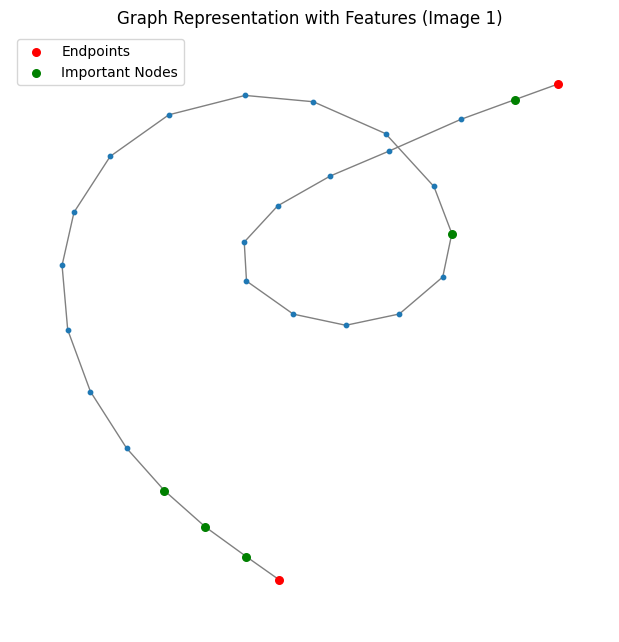

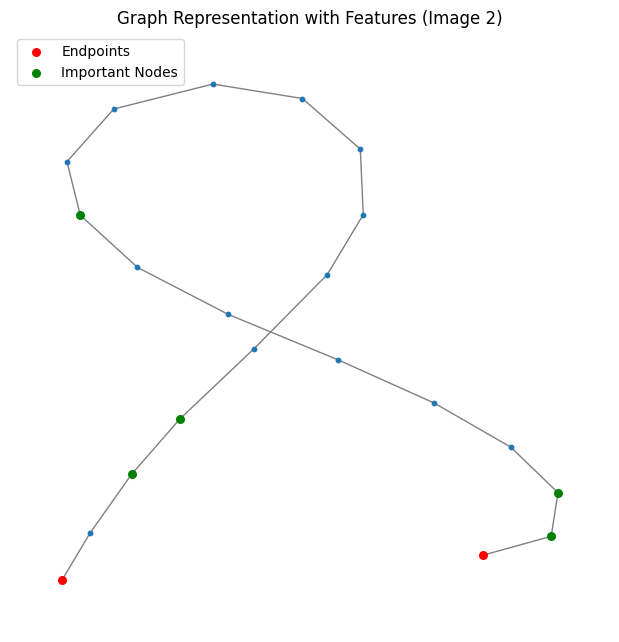

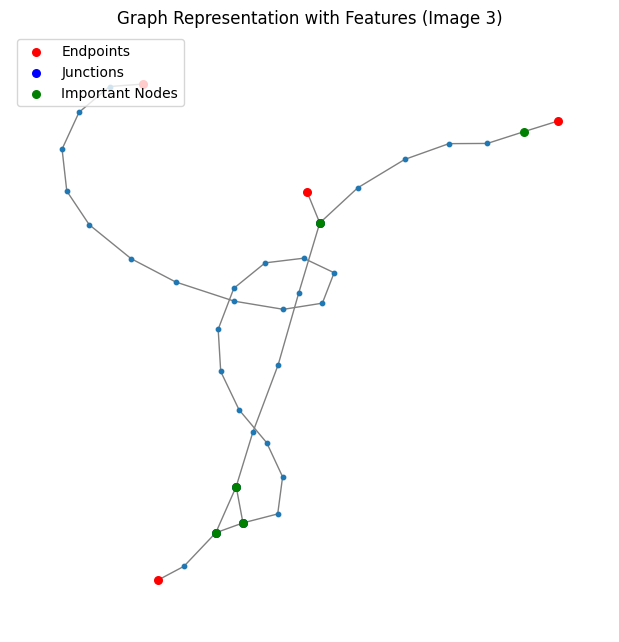

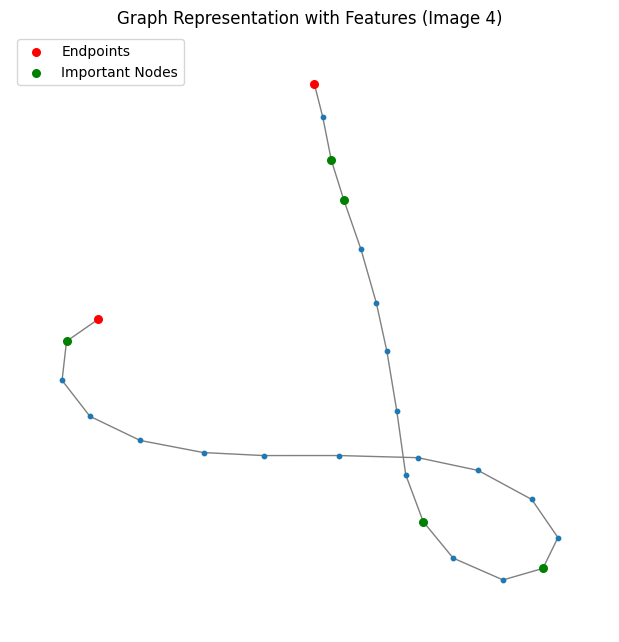

In [26]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def plot_graph_with_features(graphs):
    """
    Plot graphs with extracted features like endpoints, junctions, and important nodes.
    """
    #fixed_layout = nx.spring_layout(graphs[0], seed=42)  # Consistent layout for comparison
    for i, G in enumerate(graphs):
        plt.figure(figsize=(6, 6))
        
        # Precompute the layout (positions of nodes)
        
        # Extract endpoints and junctions
        endpoints = [node for node, degree in G.degree() if degree == 1]
        junctions = [node for node, degree in G.degree() if degree >= 3]

        # PageRank for identifying important nodes
        pagerank_scores = nx.pagerank(G)
        important_nodes = sorted(pagerank_scores, key=pagerank_scores.get, reverse=True)[:5]
        fixed_layout = nx.spring_layout(G, seed=42)  # Consistent layout for comparison

        # Plotting nodes with features
        nx.draw(G, pos=fixed_layout, with_labels=False, node_size=10, edge_color="gray")
        
        # Highlight the endpoints (red), junctions (blue), and important nodes (green)
        nx.draw_networkx_nodes(G, pos=fixed_layout, nodelist=endpoints, node_color='red', node_size=30, label="Endpoints")
        nx.draw_networkx_nodes(G, pos=fixed_layout, nodelist=junctions, node_color='blue', node_size=30, label="Junctions")
        nx.draw_networkx_nodes(G, pos=fixed_layout, nodelist=important_nodes, node_color='green', node_size=30, label="Important Nodes")
        
        plt.title(f"Graph Representation with Features (Image {i+1})")
        plt.legend(loc="upper left")
        plt.show()

# Assuming 'graphs' is a list of graphs
plot_graph_with_features(graphs)

